The type of mnist_ds: <class 'mindspore.dataset.engine.datasets_vision.MnistDataset'>
Number of pictures contained in the mnist_ds： 60000
The item of mnist_ds: dict_keys(['image', 'label'])
Tensor of image in item: (28, 28, 1)
The label of item: 1


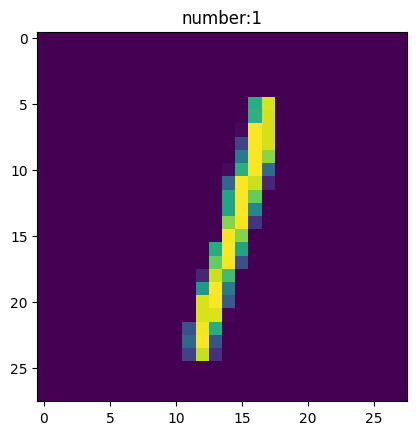

In [2]:
from mindspore import context
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import mindspore.dataset as ds

context.set_context(mode=context.GRAPH_MODE, device_target="CPU") # Windows version, set to use CPU for graph calculation
train_data_path = "../MNIST_Data/train"
test_data_path = "../MNIST_Data/test"
mnist_ds = ds.MnistDataset(train_data_path) # Load training dataset
print('The type of mnist_ds:', type(mnist_ds))
print("Number of pictures contained in the mnist_ds：",mnist_ds.get_dataset_size()) # 60000 pictures in total

dic_ds = mnist_ds.create_dict_iterator() # Convert dataset to dictionary type
item = dic_ds.__next__()
img = item["image"].asnumpy()
label = item["label"].asnumpy()

print("The item of mnist_ds:", item.keys()) # Take a single data to view the data structure, including two keys, image and label
print("Tensor of image in item:", img.shape) # View the tensor of image (28,28,1)
print("The label of item:", label)

plt.imshow(np.squeeze(img))
plt.title("number:%s"% item["label"])
plt.show()


In [4]:
# Data processing module
import mindspore.dataset.vision.c_transforms as CV
import mindspore.dataset.transforms.c_transforms as C
from mindspore.dataset.vision import Inter
from mindspore.common import dtype as mstype


def create_dataset(data_path, batch_size=32, repeat_size=1,
                   num_parallel_workers=1):
    """ create dataset for train or test
    Args:
        data_path: Data path
        batch_size: The number of data records in each group
        repeat_size: The number of replicated data records
        num_parallel_workers: The number of parallel workers
    """
    # define dataset
    mnist_ds = ds.MnistDataset(data_path)

    # Define some parameters needed for data enhancement and rough justification
    resize_height, resize_width = 32, 32
    rescale = 1.0 / 255.0
    shift = 0.0
    rescale_nml = 1 / 0.3081
    shift_nml = -1 * 0.1307 / 0.3081

    # According to the parameters, generate the corresponding data enhancement method
    resize_op = CV.Resize((resize_height, resize_width), interpolation=Inter.LINEAR)  # Resize images to (32, 32) by bilinear interpolation
    rescale_nml_op = CV.Rescale(rescale_nml, shift_nml) # normalize images
    rescale_op = CV.Rescale(rescale, shift) # rescale images
    hwc2chw_op = CV.HWC2CHW() # change shape from (height, width, channel) to (channel, height, width) to fit network.
    type_cast_op = C.TypeCast(mstype.int32) # change data type of label to int32 to fit network

    # Using map () to apply operations to a dataset
    mnist_ds = mnist_ds.map(input_columns="label", operations=type_cast_op, num_parallel_workers=num_parallel_workers)
    mnist_ds = mnist_ds.map(input_columns="image", operations=resize_op, num_parallel_workers=num_parallel_workers)
    mnist_ds = mnist_ds.map(input_columns="image", operations=rescale_op, num_parallel_workers=num_parallel_workers)
    mnist_ds = mnist_ds.map(input_columns="image", operations=rescale_nml_op, num_parallel_workers=num_parallel_workers)
    mnist_ds = mnist_ds.map(input_columns="image", operations=hwc2chw_op, num_parallel_workers=num_parallel_workers)
    # Process the generated dataset
    buffer_size = 10000
    mnist_ds = mnist_ds.shuffle(buffer_size=buffer_size)  # 10000 as in LeNet train script
    mnist_ds = mnist_ds.batch(batch_size, drop_remainder=True)
    mnist_ds = mnist_ds.repeat(repeat_size)

    return mnist_ds

In [5]:
datas = create_dataset(train_data_path) # Process the train dataset
print('Number of groups in the dataset:', datas.get_dataset_size()) # Number of query dataset groups

[WARNING] ME(23428:15192,MainProcess):2024-04-14-22:40:26.492.037 [mindspore\dataset\core\validator_helpers.py:744] 'Resize' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Resize' from mindspore.dataset.vision instead.
[WARNING] ME(23428:15192,MainProcess):2024-04-14-22:40:26.493.136 [mindspore\dataset\core\validator_helpers.py:744] 'Rescale' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Rescale' from mindspore.dataset.vision instead.
[WARNING] ME(23428:15192,MainProcess):2024-04-14-22:40:26.494.145 [mindspore\dataset\core\validator_helpers.py:744] 'Rescale' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Rescale' from mindspore.dataset.vision instead.
[WARNING] ME(23428:15192,MainProcess):2024-04-14-22:40:26.495.462 [mindspore\dataset\core\validator_helpers.py:744] 'HWC

Number of groups in the dataset: 1875


In [6]:
import mindspore.nn as nn
from mindspore.common.initializer import TruncatedNormal

# Initialize 2D convolution function
def conv(in_channels, out_channels, kernel_size, stride=1, padding=0):
    """Conv layer weight initial."""
    weight = weight_variable()
    return nn.Conv2d(in_channels, out_channels,
                     kernel_size=kernel_size, stride=stride, padding=padding,
                     weight_init=weight, has_bias=False, pad_mode="valid")

# Initialize full connection layer
def fc_with_initialize(input_channels, out_channels):
    """Fc layer weight initial."""
    weight = weight_variable()
    bias = weight_variable()
    return nn.Dense(input_channels, out_channels, weight, bias)

# Set truncated normal distribution
def weight_variable():
    """Weight initial."""
    return TruncatedNormal(0.02)

**why no bias?**  
如果卷积层后面紧接着一个偏置项或者包含偏置的层（比如一个全连接层或者一个批量归一化层），  
那么卷积层的偏置项可能就不那么重要了。因为后续的偏置项或者批量归一化会调整平均激活的水平。  
**why truncatednormal?**  
对于标准差为 0.02 的截断正态分布，大部分生成的数值将在 -0.02 到 0.02 之间。  
这样初始化权重有利于保证权重的初值都比较小而且接近于0，有助于神经网络的训练。

In [7]:
class LeNet5(nn.Cell):
    """Lenet network structure."""
    # define the operator required
    def __init__(self):
        super(LeNet5, self).__init__()
        self.batch_size = 32 # 32 pictures in each group
        self.conv1 = conv(1, 6, 5) # Convolution layer 1, 1 channel input (1 Figure), 6 channel output (6 figures), convolution core 5 * 5
        self.conv2 = conv(6, 16, 5) # Convolution layer 2,6-channel input, 16 channel output, convolution kernel 5 * 5
        self.fc1 = fc_with_initialize(16 * 5 * 5, 120)
        self.fc2 = fc_with_initialize(120, 84)
        self.fc3 = fc_with_initialize(84, 10)
        self.sigmoid = nn.Sigmoid()
        self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()

    # use the preceding operators to construct networks
    def construct(self, x):
        x = self.conv1(x) # 1*32*32-->6*28*28
        x = self.sigmoid(x) 
        x = self.max_pool2d(x) # Pool layer 6*28*28-->6*14*14
        x = self.conv2(x) # Convolution layer 6*14*14-->16*10*10
        x = self.sigmoid(x) # Function excitation layer
        x = self.max_pool2d(x) # Pool layer 16*5*5
        x = self.flatten(x) # Dimensionality reduction展平为400维
        x = self.fc1(x) # Full connection
        x = self.sigmoid(x) # Function excitation layer
        x = self.fc2(x) # Full connection
        x = self.sigmoid(x) # Function excitation layer
        x = self.fc3(x) # Full connection
        return x

In [8]:
network = LeNet5()
print(network)


LeNet5<
  (conv1): Conv2d<input_channels=1, output_channels=6, kernel_size=(5, 5), stride=(1, 1), pad_mode=valid, padding=0, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.TruncatedNormal object at 0x0000022B9609BDC0>, bias_init=None, format=NCHW>
  (conv2): Conv2d<input_channels=6, output_channels=16, kernel_size=(5, 5), stride=(1, 1), pad_mode=valid, padding=0, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.TruncatedNormal object at 0x0000022B9F316A30>, bias_init=None, format=NCHW>
  (fc1): Dense<input_channels=400, output_channels=120, has_bias=True>
  (fc2): Dense<input_channels=120, output_channels=84, has_bias=True>
  (fc3): Dense<input_channels=84, output_channels=10, has_bias=True>
  (sigmoid): Sigmoid<>
  (max_pool2d): MaxPool2d<kernel_size=2, stride=2, pad_mode=VALID>
  (flatten): Flatten<>
  >


第一个参数 1：这个参数表示输入的通道数量。在此例中，因为输入是黑白图像，所以通道数为1。如果输入图像是彩色的RGB图像，这个数值通常设置为3。  
第二个参数 6：这个参数表示输出通道的数量，也就是卷积层中的滤波器数。这里有6个滤波器用于提取输入图像的不同特征，所以输出通道的数量为6。  
第三个参数 5：这个参数表示滤波器的大小，也就是每个滤波器覆盖输入图像的区域大小。在这个例子中，每个滤波器的大小是5x5像素。

In [9]:
#搭建训练网络并训练
# Training and testing related modules
import argparse
from mindspore import Tensor
from mindspore.train.serialization import load_checkpoint, load_param_into_net
from mindspore.train.callback import ModelCheckpoint, CheckpointConfig, LossMonitor,Callback
from mindspore.train import Model
from mindspore.nn.metrics import Accuracy
from mindspore.nn.loss import SoftmaxCrossEntropyWithLogits

def train_net(model, epoch_size, mnist_path, repeat_size, ckpoint_cb, step_loss_info):
    """Define the training method."""
    print("============== Starting Training ==============")
    # load training dataset
    ds_train = create_dataset(os.path.join(mnist_path, "train"), 32, repeat_size)
    model.train(epoch_size, ds_train, callbacks=[ckpoint_cb, LossMonitor(),step_loss_info], dataset_sink_mode=True)

In [10]:
# Custom callback function
class Step_loss_info(Callback):
    def step_end(self, run_context):
        cb_params = run_context.original_args()
        # step_ Loss dictionary for saving loss value and step number information
        step_loss["loss_value"].append(str(cb_params.net_outputs))
        step_loss["step"].append(str(cb_params.cur_step_num))

run_context是在训练过程中自动产生的。当你在运行包含回调函数的训练流程时，例如在MindSpore框架中使用Model.train函数，  
RunContext对象会在每次执行回调函数时自动传入函数中。例如，在你的代码中使用step_end函数，在每一个训练步骤结束后，这个  
函数就会被调用，同时，一个RunContext对象会被自动创建并作为参数传入函数。这种工作方式允许你在每个训练步骤结束后能够获  
取当前步骤的一些具体细节，包括模型的输出和当前步骤数。你无需自己创建和管理RunContext对象，这都由框架自动完成，你只需  
要关注如何使用这些信息就可以了。

In [11]:
class EpochLossMonitor(Callback):
    def __init__(self):
        super(EpochLossMonitor, self).__init__()
        self.losses = []

    def step_end(self, run_context):
        """
        Collect training loss at the end of step.

        Args:
            run_context (RunContext): Include some information of the model.  For more details,
                    please refer to :class:`mindspore.train.RunContext`.
        """
        cb_params = run_context.original_args()
        loss = _handle_loss(cb_params.net_outputs)
        self.losses.append(loss)

    def epoch_end(self, run_context):
        """
        Print average training loss at the end of epoch.

        Args:
            run_context (RunContext): Include some information of the model.  For more details,
                    please refer to :class:`mindspore.train.RunContext`.
        """
        avg_loss = np.mean(self.losses)
        print(f"Average loss in epoch {run_context.original_args().cur_epoch_num} is: {avg_loss}")
        self.losses = []

In [12]:
from mindspore.nn.loss import MSELoss

In [ ]:
import os

if os.name == "nt":
    os.system('del/f/s/q *.ckpt *.meta')# Clean up old run files before in Windows
else:
    os.system('rm -f *.ckpt *.meta *.pb')# Clean up old run files before in Linux

lr = 0.01 # learning rate
momentum = 0.9 #

# create the network
network = LeNet5()

#动量法
# define the optimizer
net_opt = nn.Momentum(network.trainable_params(), lr, momentum)


# define the loss function
#1.交叉熵损失
net_loss = SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
#2.MSEloss
#net_loss= MSELoss(reduction='mean')


# define the model
model = Model(network, net_loss, net_opt, metrics={"Accuracy": Accuracy()} )
epoch_size = 10
mnist_path = "../MNIST_Data"

config_ck = CheckpointConfig(save_checkpoint_steps=1875, keep_checkpoint_max=10)
# save the network model and parameters for subsequence fine-tuning
ckpoint_cb = ModelCheckpoint(prefix="checkpoint_lenet", config=config_ck)
# group layers into an object with training and evaluation features
step_loss = {"step": [], "loss_value": []}
# step_ Loss dictionary for saving loss value and step number information
step_loss_info = Step_loss_info()
# save the steps and loss value
repeat_size = 1
train_net(model, epoch_size, mnist_path, repeat_size, ckpoint_cb, step_loss_info)

[WARNING] ME(23428:15192,MainProcess):2024-04-14-22:40:50.294.052 [mindspore\dataset\core\validator_helpers.py:744] 'Resize' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Resize' from mindspore.dataset.vision instead.
[WARNING] ME(23428:15192,MainProcess):2024-04-14-22:40:50.294.052 [mindspore\dataset\core\validator_helpers.py:744] 'Rescale' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Rescale' from mindspore.dataset.vision instead.
[WARNING] ME(23428:15192,MainProcess):2024-04-14-22:40:50.294.052 [mindspore\dataset\core\validator_helpers.py:744] 'Rescale' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Rescale' from mindspore.dataset.vision instead.
[WARNING] ME(23428:15192,MainProcess):2024-04-14-22:40:50.294.052 [mindspore\dataset\core\validator_helpers.py:744] 'HWC

============== Starting Training ==============
epoch: 1 step: 1, loss is 2.3071844577789307
epoch: 1 step: 2, loss is 2.3071846961975098
epoch: 1 step: 3, loss is 2.28531813621521
epoch: 1 step: 4, loss is 2.3359861373901367
epoch: 1 step: 5, loss is 2.2987325191497803
epoch: 1 step: 6, loss is 2.3166441917419434
epoch: 1 step: 7, loss is 2.316586971282959
epoch: 1 step: 8, loss is 2.3208489418029785
epoch: 1 step: 9, loss is 2.301887035369873
epoch: 1 step: 10, loss is 2.2918753623962402
epoch: 1 step: 11, loss is 2.3009819984436035
epoch: 1 step: 12, loss is 2.3238794803619385
epoch: 1 step: 13, loss is 2.2838950157165527
epoch: 1 step: 14, loss is 2.3357479572296143
epoch: 1 step: 15, loss is 2.2859928607940674
epoch: 1 step: 16, loss is 2.318796157836914
epoch: 1 step: 17, loss is 2.3203372955322266
epoch: 1 step: 18, loss is 2.3241024017333984
epoch: 1 step: 19, loss is 2.315748929977417
epoch: 1 step: 20, loss is 2.299574136734009
epoch: 1 step: 21, loss is 2.363065719604492
epo

In [1]:
steps = step_loss["step"]
loss_value = step_loss["loss_value"]
steps = list(map(int, steps))
steps_epoch=steps[::1875]
loss_value = list(map(float, loss_value))
loss_value_epoch=loss_value[::1875]
print(len(steps))
plt.plot(steps_epoch, loss_value_epoch, color="red")
plt.xlabel("Steps")
plt.ylabel("Loss_value")
plt.title("Loss function value change chart")
plt.show()


NameError: name 'step_loss' is not defined

In [16]:
def test_net(network, model, mnist_path):
    """Define the evaluation method."""
    print("============== Starting Testing ==============")
    # load the saved model for evaluation
    param_dict = load_checkpoint("checkpoint_lenet-10_1875.ckpt")
    # load parameter to the network
    load_param_into_net(network, param_dict)
    # load testing dataset
    ds_eval = create_dataset(os.path.join(mnist_path, "test"))
    acc = model.eval(ds_eval, dataset_sink_mode=True)
    print("============== Accuracy:{} ==============".format(acc))

test_net(network, model, mnist_path)


[WARNING] ME(13164:23952,MainProcess):2024-04-14-22:04:07.380.697 [mindspore\dataset\core\validator_helpers.py:744] 'Resize' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Resize' from mindspore.dataset.vision instead.
[WARNING] ME(13164:23952,MainProcess):2024-04-14-22:04:07.381.733 [mindspore\dataset\core\validator_helpers.py:744] 'Rescale' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Rescale' from mindspore.dataset.vision instead.
[WARNING] ME(13164:23952,MainProcess):2024-04-14-22:04:07.382.739 [mindspore\dataset\core\validator_helpers.py:744] 'Rescale' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Rescale' from mindspore.dataset.vision instead.
[WARNING] ME(13164:23952,MainProcess):2024-04-14-22:04:07.383.243 [mindspore\dataset\core\validator_helpers.py:744] 'HWC

============== Starting Testing ==============
============== Accuracy:{'Accuracy': 0.9861778846153846} ==============


[WARNING] ME(13164:23952,MainProcess):2024-04-14-22:04:13.219.547 [mindspore\dataset\core\validator_helpers.py:744] 'Resize' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Resize' from mindspore.dataset.vision instead.
[WARNING] ME(13164:23952,MainProcess):2024-04-14-22:04:13.220.547 [mindspore\dataset\core\validator_helpers.py:744] 'Rescale' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Rescale' from mindspore.dataset.vision instead.
[WARNING] ME(13164:23952,MainProcess):2024-04-14-22:04:13.221.609 [mindspore\dataset\core\validator_helpers.py:744] 'Rescale' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'Rescale' from mindspore.dataset.vision instead.
[WARNING] ME(13164:23952,MainProcess):2024-04-14-22:04:13.221.609 [mindspore\dataset\core\validator_helpers.py:744] 'HWC

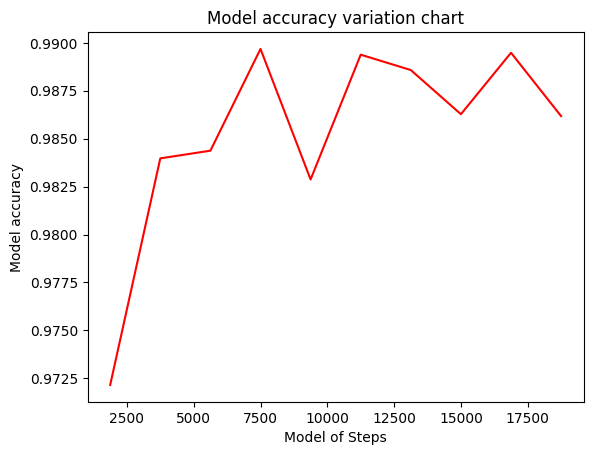

In [17]:
def acc_model_info(network, model, mnist_path, epoch_size):
    """Define the plot info method"""
    step_list = []
    acc_list = []
    for i in range(1, epoch_size +1):
        # load the saved model for evaluation
        #加载同一个模型得到的模型训练步数变化，精度随之变化
        #param_dict = load_checkpoint("checkpoint_lenet-1_1875.ckpt")
        #加载不同一个模型得到的模型训练步数变化，精度随之变化
        param_dict = load_checkpoint("checkpoint_lenet-{}_1875.ckpt".format(str(i)))
        # load parameter to the network
        load_param_into_net(network, param_dict)
        ds_eval = create_dataset(os.path.join(mnist_path, "test"))
        acc = model.eval(ds_eval, dataset_sink_mode=True)
        acc_list.append(acc['Accuracy'])
        step_list.append(i*1875)
        # load testing dataset
    # for i in range(1, model_numbers +1):
    #     ds_eval = create_dataset(os.path.join(mnist_path, "test"))
    #     acc = model.eval(ds_eval, dataset_sink_mode=True)
    #     acc_list.append(acc['Accuracy'])
    #     step_list.append(i*125)
    return step_list,acc_list

# Draw line chart according to training steps and model accuracy
l1,l2 = acc_model_info(network, model, mnist_path,10)
plt.xlabel("Model of Steps")
plt.ylabel("Model accuracy")
plt.title("Model accuracy variation chart")
plt.plot(l1, l2, 'red')
plt.show()
